
# Tutorial 10 — **Herramientas estadísticas en Python**


**Objetivo**: Usar **scipy.stats**, **statsmodels** y **pandas** para (1) ejecutar **pruebas de hipótesis**, (2) calcular **correlaciones** y (3) **evaluar supuestos** estadísticos (normalidad, varianzas).  




<a id="material"></a>
## 1) Material de estudio



<a id="libs-data"></a>
### 1.1 Librerías y **datos de ejemplo** (sintéticos reproducibles)

Generamos un dataset pequeño para practicar: grupos **A**/**B** con una métrica continua (`score`), conversión binaria (`conversion`) para pruebas de proporciones, y pares `antes`/`despues` para una prueba **pareada**. Además, creamos variables para **correlación** (una relación lineal y otra monótona no lineal).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm
from statsmodels.stats import weightstats as stw
from statsmodels.stats import diagnostic as smdiag
from statsmodels.stats import stattools as smstat
from statsmodels.graphics.gofplots import qqplot

In [2]:
np.random.seed(123)

# --- Datos sintéticos ---
nA, nB = 120, 110
grupo = np.array(["A"]*nA + ["B"]*nB)

# Métrica continua por grupo (A: media ~50, B: media ~54)
score_A = np.random.normal(loc=50, scale=8, size=nA)
score_B = np.random.normal(loc=54, scale=8, size=nB)

# Inyectar algunos outliers leves
score_A[:3] += np.array([22, -18, 15])
score_B[:3] += np.array([20, -17, 10])

# Conversión binaria (A: p~0.28, B: p~0.36)
conv_A = (np.random.rand(nA) < 0.28).astype(int)
conv_B = (np.random.rand(nB) < 0.36).astype(int)

# Pares antes/despues (misma persona; mejora moderada)
antes = np.random.normal(60, 10, size=80)
despues = antes + np.random.normal(4, 6, size=80)  # mejora ~ +4 promedio

# Variables para correlación
x = np.linspace(-3, 3, 200)
y_lin = 0.6*x + np.random.normal(0, 0.5, size=len(x))          # relación lineal
y_nonlin = np.sign(x) * (x**2)/4 + np.random.normal(0, 0.5, len(x))  # monótona no lineal

df = pd.DataFrame({
    "grupo": grupo,
    "score": np.concatenate([score_A, score_B]),
    "conversion": np.concatenate([conv_A, conv_B])
})

print("Estructura del DataFrame:")
print(df.head())
print("\nFilas/Columnas:", df.shape)
print("Conteo por grupo:")
print(df["grupo"].value_counts())

Estructura del DataFrame:
  grupo      score  conversion
0     A  63.314955           0
1     A  39.978764           0
2     A  67.263828           0
3     A  37.949642           1
4     A  45.371198           0

Filas/Columnas: (230, 3)
Conteo por grupo:
A    120
B    110
Name: grupo, dtype: int64



<a id="supuestos"></a>
### 1.2 **Supuestos y diagnósticos** mínimos

- **Normalidad** (p. ej., **Shapiro–Wilk**): útil para decidir entre pruebas paramétricas (t‑test) o alternativas robustas.  
- **Homocedasticidad** (varianzas iguales entre grupos, p. ej., **Levene**): define si usar `equal_var=True/False` en `ttest_ind`.  
- **Inspección visual**: **QQ‑plot** de residuos/variables, histogramas y *boxplots* ayudan a detectar asimetrías y *outliers* 

In [3]:

print("Chequeo de supuestos para score por grupo (A vs B)...")

score_A = df.loc[df["grupo"]=="A","score"].values
score_B = df.loc[df["grupo"]=="B","score"].values

# Normalidad (Shapiro) - muestra < 5000; p<0.05 sugiere no-normalidad
sh_A = stats.shapiro(score_A)
sh_B = stats.shapiro(score_B)
print(f"Shapiro A: estad={sh_A.statistic:.3f}, p={sh_A.pvalue:.4f}")
print(f"Shapiro B: estad={sh_B.statistic:.3f}, p={sh_B.pvalue:.4f}")


Chequeo de supuestos para score por grupo (A vs B)...
Shapiro A: estad=0.988, p=0.4081
Shapiro B: estad=0.977, p=0.0511


In [4]:

# Homogeneidad de varianzas (Levene)
lev = stats.levene(score_A, score_B, center="median")
print(f"Levene (varianzas iguales?): estad={lev.statistic:.3f}, p={lev.pvalue:.4f}")


Levene (varianzas iguales?): estad=9.672, p=0.0021


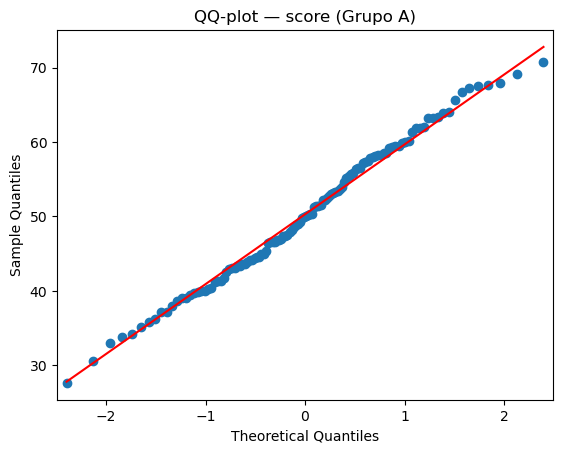

In [5]:

# QQ‑plot para score_A (una figura)
fig = qqplot(score_A, line="s")
plt.title("QQ‑plot — score (Grupo A)")
plt.show()


<a id="tests"></a>
### 1.3 **Pruebas de hipótesis** (paramétricas comunes)

Incluimos ejemplos típicos:  
- **t de una muestra** (media vs valor de referencia)  
- **t de dos muestras independientes** (A vs B; con/ sin varianzas iguales)  
- **t pareada** (antes vs después, mismas unidades)  
- **Proporciones** (comparación de tasas de conversión)  
Además reportamos **tamaños de efecto** y, cuando aplica, **intervalos de confianza (IC)**.


In [6]:

# Funciones auxiliares
def cohens_d_ind(x, y):
    """"
    Cohen's d para dos muestras independientes.
    Calcula (media(x) - media(y)) dividido por la desviación estándar
    combinada de ambas muestras, usando ddof=1.
    Devuelve el tamaño de efecto en desviaciones estándar.
    """
    nx, ny = len(x), len(y)
    vx, vy = np.var(x, ddof=1), np.var(y, ddof=1)
    s_p = np.sqrt(((nx-1)*vx + (ny-1)*vy) / (nx+ny-2))
    return (np.mean(x) - np.mean(y)) / s_p

def cohens_d_paired(x, y):
    """
    Cohen's d para muestras pareadas (pre–post).
    Calcula la media de las diferencias (x - y) dividida por la
    desviación estándar de dichas diferencias, usando ddof=1.
    También se conoce como d_z.
    """
    d = x - y
    return np.mean(d) / np.std(d, ddof=1)


In [7]:

print("1) t de UNA muestra — ¿score_A ~ 50?")
t1 = stats.ttest_1samp(score_A, popmean=50)
print(f"t={t1.statistic:.3f}, p={t1.pvalue:.4f}")
print(f"media_A={np.mean(score_A):.2f} (H0: 50)")



1) t de UNA muestra — ¿score_A ~ 50?
t=0.334, p=0.7390
media_A=50.29 (H0: 50)


In [8]:
print("\n2) t de DOS muestras independientes — A vs B")
equal_var = lev.pvalue >= 0.05
t2 = stats.ttest_ind(score_A, score_B, equal_var=equal_var)
d_ind = cohens_d_ind(score_A, score_B)
print(f"equal_var={equal_var} -> t={t2.statistic:.3f}, p={t2.pvalue:.4f}, d={d_ind:.3f}")


2) t de DOS muestras independientes — A vs B
equal_var=False -> t=-3.102, p=0.0022, d=-0.406


In [9]:
print("\n3) t PAREADA — antes vs despues")
t3 = stats.ttest_rel(antes, despues)
d_pair = cohens_d_paired(despues, antes)  # mejora (despues - antes)
print(f"   t={t3.statistic:.3f}, p={t3.pvalue:.4f}, d_pareado={d_pair:.3f}")
print(f"   medias: antes={np.mean(antes):.2f} vs despues={np.mean(despues):.2f}")



3) t PAREADA — antes vs despues
   t=-6.465, p=0.0000, d_pareado=0.723
   medias: antes=60.19 vs despues=64.50


In [10]:

print("\n4) Prueba de PROPORCIONES — conversión A vs B")
from statsmodels.stats.proportion import proportions_ztest
conv = df.groupby("grupo")["conversion"].agg(["sum","count"])
succ = conv.loc[["A","B"], "sum"].values
nobs = conv.loc[["A","B"], "count"].values
z_stat, p_val = proportions_ztest(succ, nobs)
rate_A, rate_B = succ[0]/nobs[0], succ[1]/nobs[1]
print(f"   z={z_stat:.3f}, p={p_val:.4f} | tasas: A={rate_A:.3f}, B={rate_B:.3f}")


4) Prueba de PROPORCIONES — conversión A vs B
   z=-2.147, p=0.0318 | tasas: A=0.267, B=0.400



<a id="correlacion"></a>
### 1.4 **Correlación**: **Pearson** (lineal) vs **Spearman** (rangos)

- **Pearson** captura **relación lineal** (supone variables continuas y aproximadamente normales).  
- **Spearman** usa **rangos** y es más robusto ante **relaciones monótonas no lineales** y *outliers*.  
Esto está alineado con las recomendaciones de exploración estadística y correlaciones de tu clase de exploración avanzada.


In [11]:
from scipy.stats import pearsonr, spearmanr

print("Correlaciones para relación lineal (x ~ y_lin):")
r_p_lin, p_p_lin = pearsonr(x, y_lin)
r_s_lin, p_s_lin = spearmanr(x, y_lin)
print(f"  Pearson r={r_p_lin:.3f} (p={p_p_lin:.4f}) | Spearman ρ={r_s_lin:.3f} (p={p_s_lin:.4f})")

print("\nCorrelaciones para relación monótona no lineal (x ~ y_nonlin):")
r_p_nl, p_p_nl = pearsonr(x, y_nonlin)
r_s_nl, p_s_nl = spearmanr(x, y_nonlin)
print(f"  Pearson r={r_p_nl:.3f} (p={p_p_nl:.4f}) | Spearman ρ={r_s_nl:.3f} (p={p_s_nl:.4f})")

Correlaciones para relación lineal (x ~ y_lin):
  Pearson r=0.895 (p=0.0000) | Spearman ρ=0.903 (p=0.0000)

Correlaciones para relación monótona no lineal (x ~ y_nonlin):
  Pearson r=0.876 (p=0.0000) | Spearman ρ=0.879 (p=0.0000)


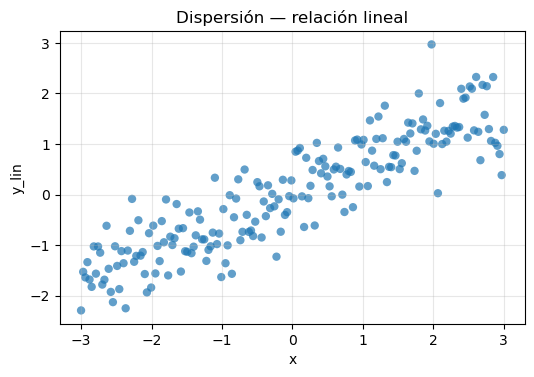

In [12]:
# Gráficos de dispersión (una figura por caso)
fig, ax = plt.subplots(figsize=(6,3.8))
ax.scatter(x, y_lin, alpha=0.7, edgecolor="none")
ax.set_title("Dispersión — relación lineal")
ax.set_xlabel("x"); ax.set_ylabel("y_lin")
ax.grid(True, alpha=0.3)
plt.show()

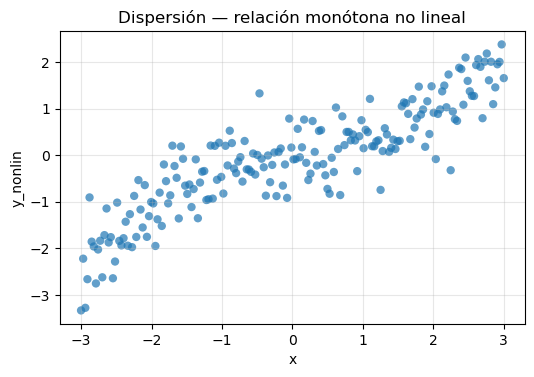

In [13]:

fig, ax = plt.subplots(figsize=(6,3.8))
ax.scatter(x, y_nonlin, alpha=0.7, edgecolor="none")
ax.set_title("Dispersión — relación monótona no lineal")
ax.set_xlabel("x"); ax.set_ylabel("y_nonlin")
ax.grid(True, alpha=0.3)
plt.show()


<a id="statsmodels"></a>
### 1.5 Mini‑flujo con **statsmodels** (OLS + diagnósticos)

Ajustamos un modelo lineal simple `y_lin ~ x` y revisamos **residuos**: **QQ‑plot** (normalidad) y **Breusch‑Pagan** (homocedasticidad).

In [14]:
X = sm.add_constant(x)
ols = sm.OLS(y_lin, X).fit()
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.800
Model:                            OLS   Adj. R-squared:                  0.799
Method:                 Least Squares   F-statistic:                     793.9
Date:                Thu, 06 Nov 2025   Prob (F-statistic):           3.33e-71
Time:                        20:39:28   Log-Likelihood:                -145.85
No. Observations:                 200   AIC:                             295.7
Df Residuals:                     198   BIC:                             302.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0319      0.036      0.895      0.3

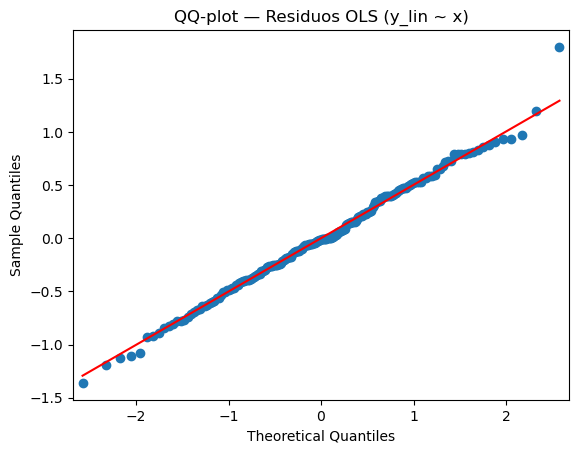

In [15]:
# Residuos
res = ols.resid

# QQ‑plot de residuos
fig = qqplot(res, line="s")
plt.title("QQ‑plot — Residuos OLS (y_lin ~ x)")
plt.show()

In [16]:
# Breusch-Pagan (heterocedasticidad)
bp = smdiag.het_breuschpagan(res, X)
bp_stat, bp_pvalue = bp[0], bp[1]
print(f"Breusch-Pagan: estad={bp_stat:.3f}, p={bp_pvalue:.4f}")

Breusch-Pagan: estad=1.880, p=0.1703



<a id="ejercicios"></a>
## 2) Ejercicios

> **Formato**: usa mensajes `print(...)` **descriptivos**, incluye títulos y ejes en figuras, y justifica brevemente tu decisión estadística (p. ej., por qué Pearson vs Spearman).



### Ejercicio 1 — Supuestos y elección de prueba
1. Con `df['score']` por grupo, aplica **Shapiro** (A y B) y **Levene**.  
2. Según los resultados, decide si usar `ttest_ind` con `equal_var=True/False`.  


In [17]:

# Tu solución aquí



### Ejercicio 2 — Proporciones
1. Compara **tasas de conversión** A vs B con `proportions_ztest`.  
2. Muestra el **z**, **p** y las tasas por grupo, e interpreta en una línea.


In [18]:

# Tu solución aquí



### Ejercicio 3 — Correlación y visualización
1. Calcula **Pearson** y **Spearman** entre `x` y `y_nonlin`.  
2. ¿Cuál reportarías y por qué? Muestra un **dispersión** para justificar.


In [19]:

# Tu solución aquí
from scipy.stats import pearsonr, spearmanr



### Ejercicio 4 — OLS y supuestos
1. Ajusta `OLS(y_lin ~ x)` con **statsmodels**; imprime el **resumen**.  
2. Revisa **QQ‑plot** de residuos y corre **Breusch‑Pagan**; interpreta `p`.


In [20]:

# Tu solución aquí